In [1]:
import pandas

⏱️ Temps moyen par chunk : 55.22 secondes


/var/folders/98/d7v0gf4d605852bg8c2jb6gw0000gp/T/ipykernel_97338/921153786.py:64: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


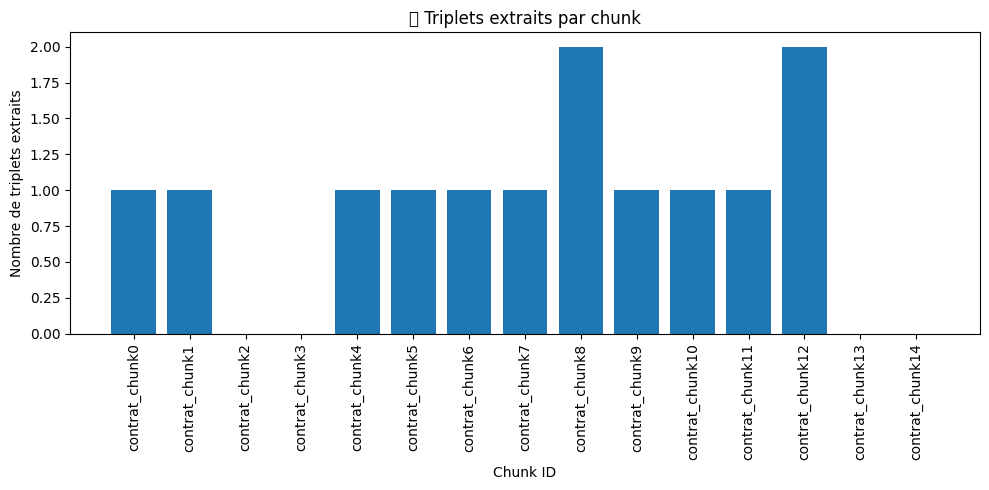

In [7]:
import re
from datetime import datetime
import matplotlib.pyplot as plt

log_file = "graphrag.log"

# Regex
start_model_pattern = re.compile(r"(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d+).*Loading triplet extraction model.*")
chunk_id_pattern = re.compile(r".*Processing chunk (\S+) for triplet extraction")
end_chunk_pattern = re.compile(r"(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d+).*Extracted and processed (\d+) triplets from chunk (\S+)")

chunk_infos = []

with open(log_file, "r", encoding="utf-8") as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i]
    start_model_match = start_model_pattern.search(line)

    if start_model_match:
        start_time = datetime.strptime(start_model_match.group(1), "%Y-%m-%d %H:%M:%S.%f")
        chunk_id = None

        # Parcours du "bloc" jusqu'au prochain "Extracted and processed"
        for j in range(i, len(lines)):  # Fenêtre raisonnable
            chunk_line = chunk_id_pattern.search(lines[j])
            if chunk_line:
                chunk_id = chunk_line.group(1)

            end_match = end_chunk_pattern.search(lines[j])
            if end_match:
                end_time = datetime.strptime(end_match.group(1), "%Y-%m-%d %H:%M:%S.%f")
                triplet_count = int(end_match.group(2))
                end_chunk_id = end_match.group(3)

                if chunk_id and chunk_id == end_chunk_id:
                    chunk_infos.append((chunk_id, start_time, end_time, triplet_count))
                break
        i = j  # on saute au bloc suivant
    else:
        i += 1

# 1. Temps moyen
durations = [(end - start).total_seconds() for _, start, end, _ in chunk_infos]
if durations:
    avg_time = sum(durations) / len(durations)
    print(f"⏱️ Temps moyen par chunk : {avg_time:.2f} secondes")
else:
    print("Aucun bloc détecté.")

# 2. Graphe du nombre de triplets
if chunk_infos:
    chunk_ids = [c[0] for c in chunk_infos]
    triplet_counts = [c[3] for c in chunk_infos]

    plt.figure(figsize=(10, 5))
    plt.bar(chunk_ids, triplet_counts)
    plt.xticks(rotation=90)
    plt.xlabel("Chunk ID")
    plt.ylabel("Nombre de triplets extraits")
    plt.title("📊 Triplets extraits par chunk")
    plt.tight_layout()
    plt.show()
